In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

PAL = {'BC': '#F97066', 'NC': '#14B8A6'}

In [24]:
df = pd.read_csv('GSE270497_All.txt', sep='\t', index_col=0)
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
metadata = pd.read_csv('GSE270497_sample_metadata.csv')


In [25]:
metadata['label'] = metadata['title'].map(lambda x: 'BC' if 'Positive' in x else 'NC')
metadata['title_1'] = metadata['title'].str.replace('Positive-|Negative-', '', regex=True).str.strip()
label_lookup = dict(zip(metadata['title_1'], metadata['label']))

labels = pd.Series(df.columns.map(label_lookup), index=df.columns)
n_bc = (labels == 'BC').sum()
n_nc = (labels == 'NC').sum()
print(f'BC: {n_bc}  |  NC: {n_nc}')

BC: 120  |  NC: 60


In [26]:
total_counts = df.sum(axis=0)
sparsity = (df == 0).sum().sum() / df.size
zero_per_mirna = (df == 0).sum(axis=1) / df.shape[1]

print(f'Shape           : {df.shape[0]} miRNAs × {df.shape[1]} samples')
print(f'Sparsity        : {sparsity:.1%}')
print(f'Median lib size : {total_counts.median():,.0f}')
print(f'Mean lib (BC)   : {total_counts[labels=="BC"].mean():,.0f}')
print(f'Mean lib (NC)   : {total_counts[labels=="NC"].mean():,.0f}')
print(f'Count range     : {df.min().min():.0f} – {df.max().max():,.0f}')
print(f'miRNAs >50% 0s  : {(zero_per_mirna > 0.5).sum()} / {len(zero_per_mirna)}')
print(f'miRNAs all 0s   : {(zero_per_mirna == 1.0).sum()}')

Shape           : 3538 miRNAs × 180 samples
Sparsity        : 46.6%
Median lib size : 745,813
Mean lib (BC)   : 1,072,342
Mean lib (NC)   : 933,925
Count range     : 0 – 1,840,030
miRNAs >50% 0s  : 1644 / 3538
miRNAs all 0s   : 0


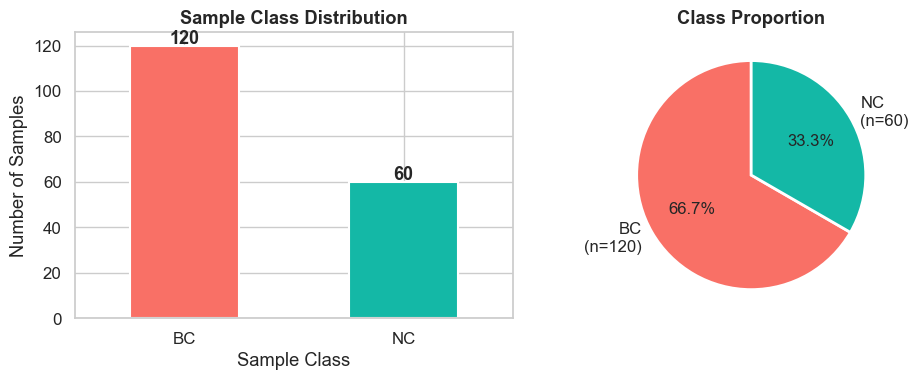

In [27]:
counts = labels.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts.plot(kind='bar', ax=axes[0], color=[PAL[c] for c in counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Sample Class Distribution', fontweight = 'bold')
axes[0].set_xlabel('Sample Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, (c, v) in enumerate(counts.items()):
    axes[0].text(i, v + 0.8, str(v), ha='center', fontweight='bold', fontsize=13)
axes[1].pie(counts, labels=[f'{c}\n(n={v})' for c, v in counts.items()],
            colors=[PAL[c] for c in counts.index], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')
plt.tight_layout()
plt.show()

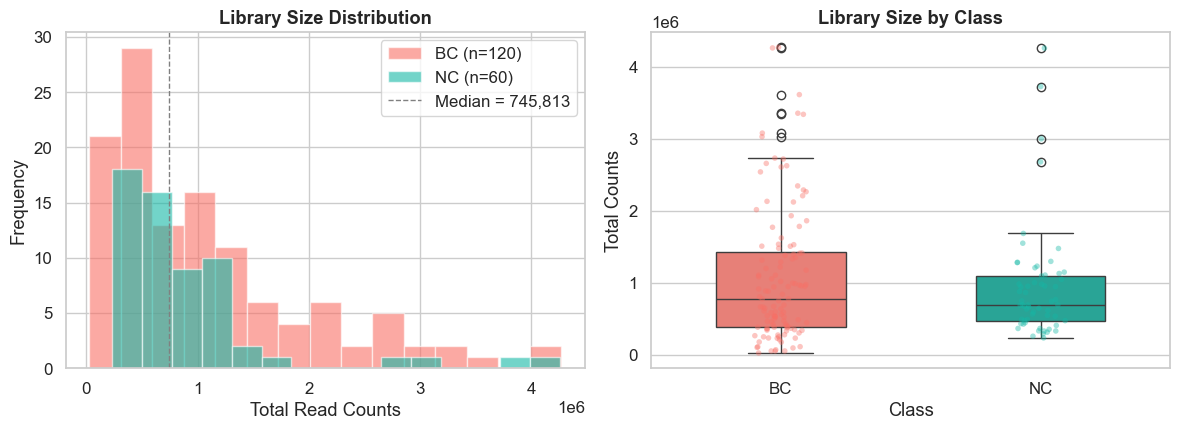

Mann-Whitney U test for library size: p = 0.8282


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for c in ['BC', 'NC']:
    m = labels == c
    axes[0].hist(total_counts[m], bins=15, alpha=0.6, label=f'{c} (n={m.sum()})',
                 color=PAL[c], edgecolor='white')
axes[0].set_title('Library Size Distribution', fontweight='bold')
axes[0].set_xlabel('Total Read Counts')
axes[0].set_ylabel('Frequency')
axes[0].axvline(total_counts.median(), color='grey', ls='--', lw=1,
                label=f'Median = {total_counts.median():,.0f}')
axes[0].legend()

lib_df = pd.DataFrame({'Total Counts': total_counts, 'Class': labels})
sns.boxplot(data=lib_df, x='Class', y='Total Counts', palette=PAL, ax=axes[1], width=0.5)
sns.stripplot(data=lib_df, x='Class', y='Total Counts', palette=PAL,
              ax=axes[1], alpha=0.4, size=4, jitter=True)
axes[1].set_title('Library Size by Class', fontweight='bold')

plt.tight_layout()
plt.show()

t_lib, p_lib = stats.mannwhitneyu(total_counts[labels == 'BC'], total_counts[labels == 'NC'])
print(f'Mann-Whitney U test for library size: p = {p_lib:.4f}')


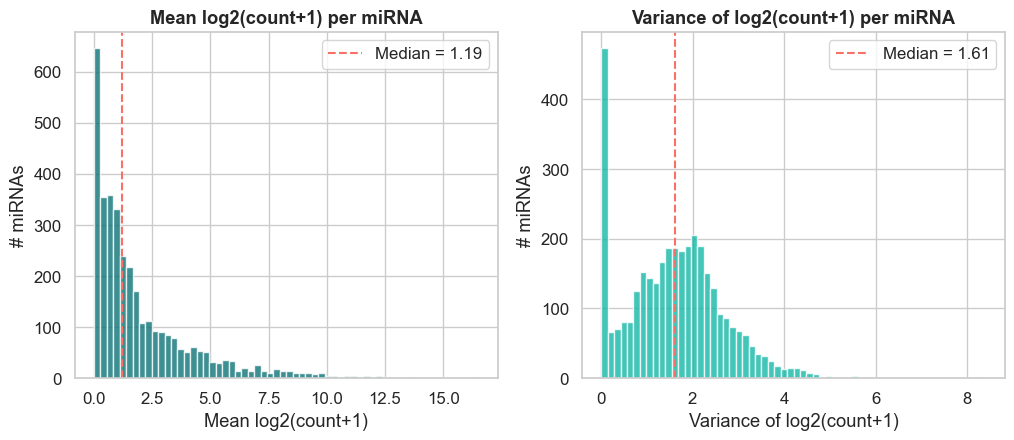

In [29]:
df_log = np.log2(df + 1)
mean_expr = df_log.mean(axis=1)
var_expr = df_log.var(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(mean_expr, bins=60, color='#0D7377', edgecolor='white', alpha=0.8)
axes[0].axvline(mean_expr.median(), color='#F97066', ls='--', lw=1.5,
                label=f'Median = {mean_expr.median():.2f}')
axes[0].set_title('Mean log2(count+1) per miRNA', fontweight='bold')
axes[0].set_xlabel('Mean log2(count+1)')
axes[0].set_ylabel('# miRNAs')
axes[0].legend()

axes[1].hist(var_expr, bins=60, color='#14B8A6', edgecolor='white', alpha=0.8)
axes[1].axvline(var_expr.median(), color='#F97066', ls='--', lw=1.5,
                label=f'Median = {var_expr.median():.2f}')
axes[1].set_title('Variance of log2(count+1) per miRNA', fontweight='bold')
axes[1].set_xlabel('Variance of log2(count+1)')
axes[1].set_ylabel('# miRNAs')
axes[1].legend()

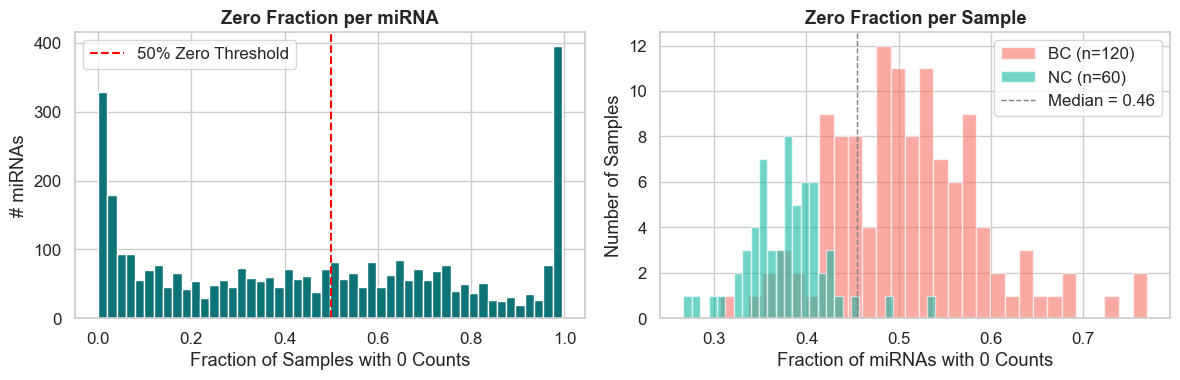

miRNAs with >50% zeros: 1644 / 3538
miRNAs with >80% zeros: 709 / 3538
Overall sparsity: 46.6%


In [30]:
zf_mirna = (df == 0).sum(axis=1) / df.shape[1]
zf_sample = (df == 0).sum(axis=0) / df.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(zf_mirna, bins=50, color='#0D7377', edgecolor='white')
axes[0].set_title('Zero Fraction per miRNA', fontweight='bold')
axes[0].set_xlabel('Fraction of Samples with 0 Counts')
axes[0].set_ylabel('# miRNAs')
axes[0].axvline(0.5, color='red', ls='--', lw=1.5, label='50% Zero Threshold')
axes[0].legend()   

for c in ['BC', 'NC']:
    m = labels == c
    axes[1].hist(zf_sample[m], bins=30, alpha=0.6, label=f'{c} (n={m.sum()})',
                 color=PAL[c], edgecolor='white')
axes[1].set_title('Zero Fraction per Sample', fontweight='bold')
axes[1].set_xlabel('Fraction of miRNAs with 0 Counts')
axes[1].set_ylabel('Number of Samples')
axes[1].axvline(zf_sample.median(), color='grey', ls='--', lw=1, label=f'Median = {zf_sample.median():.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'miRNAs with >50% zeros: {(zf_mirna > 0.5).sum()} / {len(zf_mirna)}')
print(f'miRNAs with >80% zeros: {(zf_mirna > 0.8).sum()} / {len(zf_mirna)}')
print(f'Overall sparsity: {(df == 0).sum().sum() / df.size:.1%}')

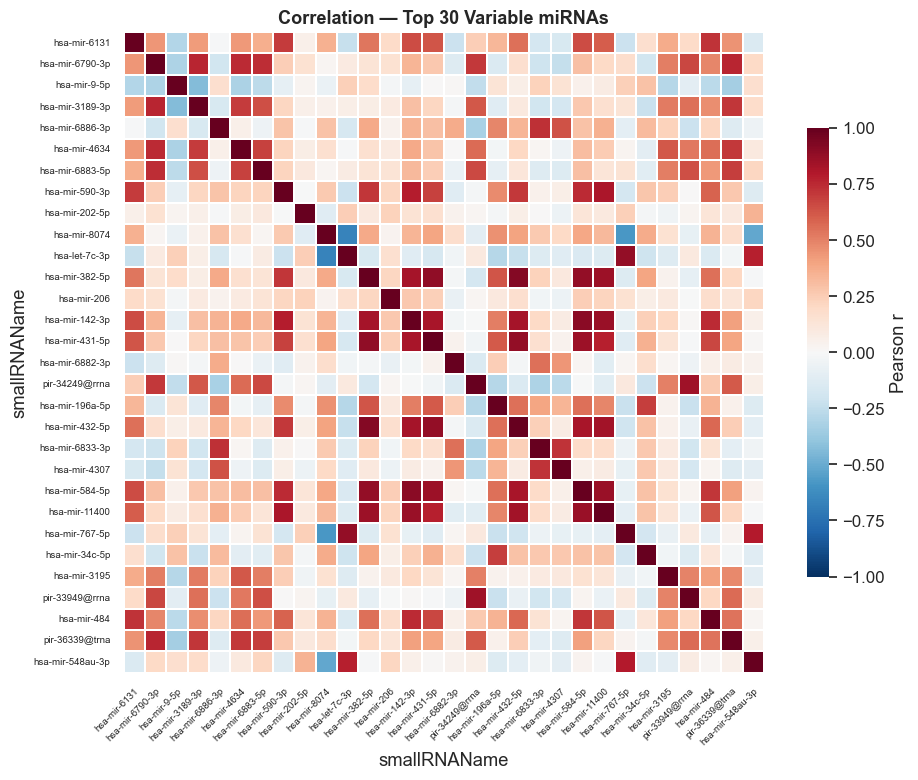

In [31]:
top30 = df_log.var(axis=1).nlargest(30).index
corr = df_log.loc[top30].T.corr()
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.2, ax=ax, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
            xticklabels=True, yticklabels=True)
ax.tick_params(labelsize=7)
ax.set_title('Correlation — Top 30 Variable miRNAs', fontweight='bold', fontsize=13)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.show()

In [32]:
filt = df_log[df_log.var(axis=1) > df_log.var(axis=1).quantile(0.25)]
X = StandardScaler().fit_transform(filt.T.values)

pca = PCA(n_components=min(10, X.shape[1]))
Xp = pca.fit_transform(X)
ve = pca.explained_variance_ratio_

print(f'PC1: {ve[0]:.1%}  |  PC2: {ve[1]:.1%}  |  Top-5 cumulative: {sum(ve[:5]):.1%}')

PC1: 13.2%  |  PC2: 5.5%  |  Top-5 cumulative: 27.3%


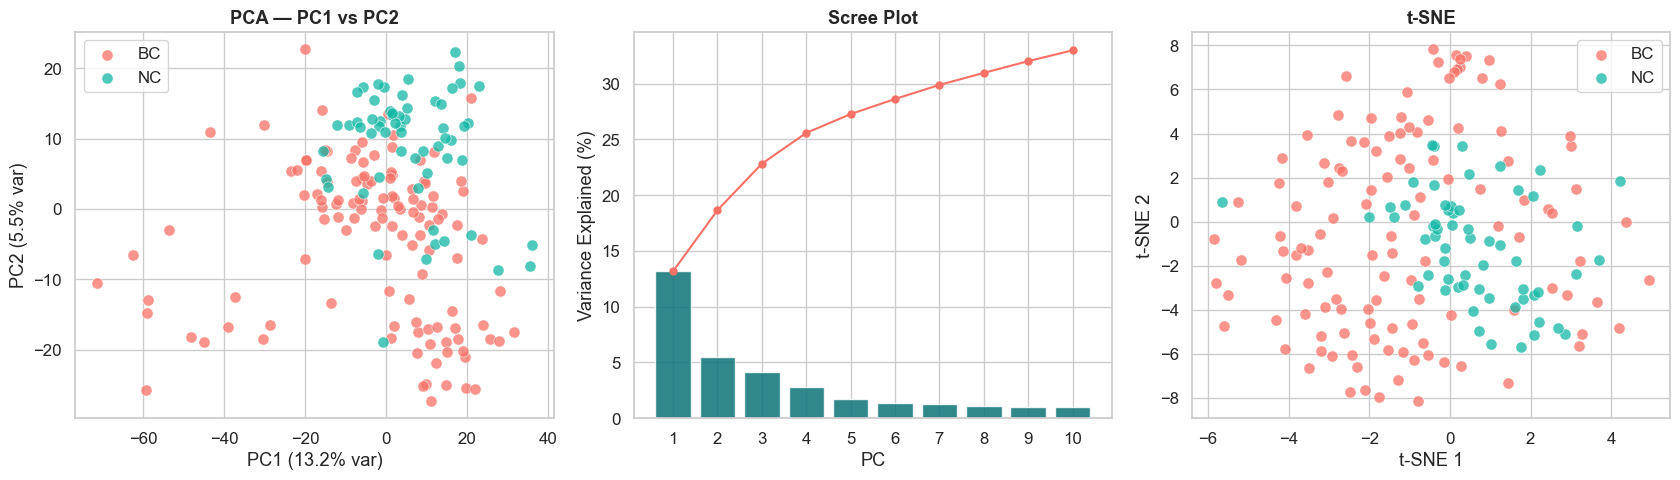

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for cls in ['BC', 'NC']:
    m = labels.values == cls
    axes[0].scatter(Xp[m, 0], Xp[m, 1], c=PAL[cls], label=cls,
                    alpha=.75, edgecolors='white', s=65, linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({ve[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({ve[1]:.1%} var)')
axes[0].set_title('PCA — PC1 vs PC2', fontweight='bold')
axes[0].legend()

axes[1].bar(range(1, len(ve)+1), ve*100, color='#0D7377', edgecolor='white', alpha=0.85)
axes[1].plot(range(1, len(ve)+1), np.cumsum(ve)*100, 'o-', color='#F97066', ms=5, lw=1.5)
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot', fontweight='bold')
axes[1].set_xticks(range(1, len(ve)+1))

tsne = TSNE(n_components=2, perplexity=25, random_state=42)
X_tsne = tsne.fit_transform(X)
for cls in ['BC', 'NC']:
    m = labels.values == cls
    axes[2].scatter(X_tsne[m, 0], X_tsne[m, 1], c=PAL[cls], label=cls,
                    alpha=.75, edgecolors='white', s=65, linewidths=0.5)
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
axes[2].set_title('t-SNE', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()


In [34]:
from statsmodels.stats.multitest import multipletests
bc_cols = labels[labels == 'BC'].index
nc_cols = labels[labels == 'NC'].index

res = []
for mi in df_log.index:
    bv = df_log.loc[mi, bc_cols].values
    nv = df_log.loc[mi, nc_cols].values
    fc = bv.mean() - nv.mean()
    _, p = stats.ttest_ind(bv, nv, equal_var=False)
    res.append({'miRNA': mi, 'log2FC': fc, 'pvalue': p})
de = pd.DataFrame(res).set_index('miRNA')
de['neg_log10_p'] = -np.log10(de['pvalue'].clip(lower=1e-300))

de['padj'] = multipletests(de['pvalue'], method='fdr_bh')[1]
sig = de[(de['padj'] < 0.05) & (de['log2FC'].abs() > 1)]
print(f'Significant DEMs (|log2FC| > 1, padj < 0.05): {len(sig)}')
print(f'Upregulated in BC:                            {(sig["log2FC"] > 0).sum()}')
print(f'Downregulated in BC:                          {(sig["log2FC"] < 0).sum()}')


Significant DEMs (|log2FC| > 1, padj < 0.05): 191
Upregulated in BC:                            9
Downregulated in BC:                          182


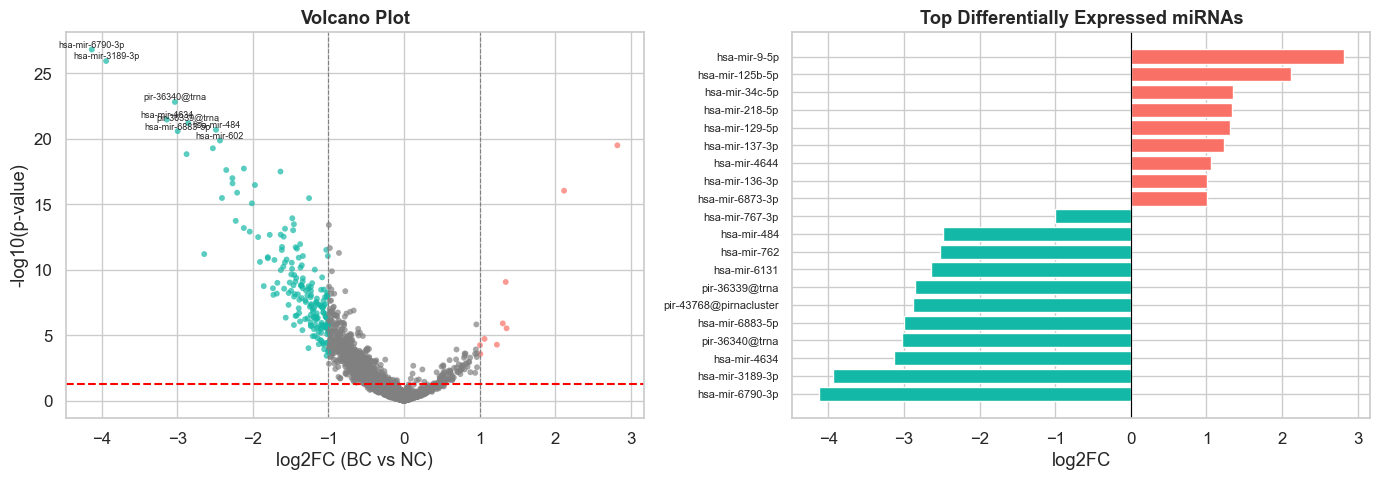

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = []
for _, r in de.iterrows():
    if r['padj'] < 0.05 and r.log2FC > 1:
        colors.append('#F97066')  # Upregulated in BC
    elif r['padj'] < 0.05 and r.log2FC < -1:
        colors.append('#14B8A6')  # Downregulated in BC
    else:
        colors.append('grey')  # Not significant

axes[0].scatter(de['log2FC'], de['neg_log10_p'], c=colors, alpha=0.7, edgecolors='none', s=18, linewidths=0.5)
axes[0].axhline(-np.log10(0.05), color = 'red', ls='--', lw=1.5, label='padj = 0.05')
axes[0].axvline(1, color='grey', ls='--', lw=0.8)
axes[0].axvline(-1, color='grey', ls='--', lw=0.8)
axes[0].set_xlabel('log2FC (BC vs NC)')
axes[0].set_ylabel('-log10(p-value)')
axes[0].set_title('Volcano Plot', fontweight='bold')

for mirna_name, r in de.nlargest(8, 'neg_log10_p').iterrows():
    axes[0].annotate(mirna_name, (r['log2FC'], r['neg_log10_p']), fontsize=6.5, ha='center',  va='bottom')

if len(sig) > 0:
    top_up = sig.nlargest(10, 'log2FC')
    top_dn = sig.nsmallest(10, 'log2FC')
    top_de = pd.concat([top_up, top_dn])
    top_de = top_de[~top_de.index.duplicated(keep='first')].sort_values('log2FC')
    axes[1].barh(range(len(top_de)), top_de['log2FC'].values,
                 color=[PAL['BC'] if fc > 0 else PAL['NC'] for fc in top_de['log2FC']],
                 edgecolor='white')   
    axes[1].set_yticks(range(len(top_de)))
    axes[1].set_yticklabels(top_de.index, fontsize=8)
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].set_xlabel('log2FC')

axes[1].set_title('Top Differentially Expressed miRNAs', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
de.sort_values('pvalue').head(15)[['log2FC', 'pvalue', 'padj']]

,log2FC,pvalue,padj
miRNA,,,
hsa-mir-6790-3p,-4.129305,1.538353e-27,5.442694e-24
hsa-mir-3189-3p,-3.939283,1.163097e-26,2.057519e-23
pir-36340@trna,-3.030297,1.552500e-23,1.830914e-20
hsa-mir-4634,-3.135850,3.483835e-22,3.081452e-19
pir-36339@trna,-2.853525,6.393820e-22,4.524267e-19
hsa-mir-484,-2.486426,2.081022e-21,1.227109e-18
hsa-mir-6883-5p,-2.993161,2.625734e-21,1.327121e-18
hsa-mir-602,-2.434201,1.374876e-20,6.080390e-18
hsa-mir-9-5p,2.820873,3.180635e-20,1.250343e-17


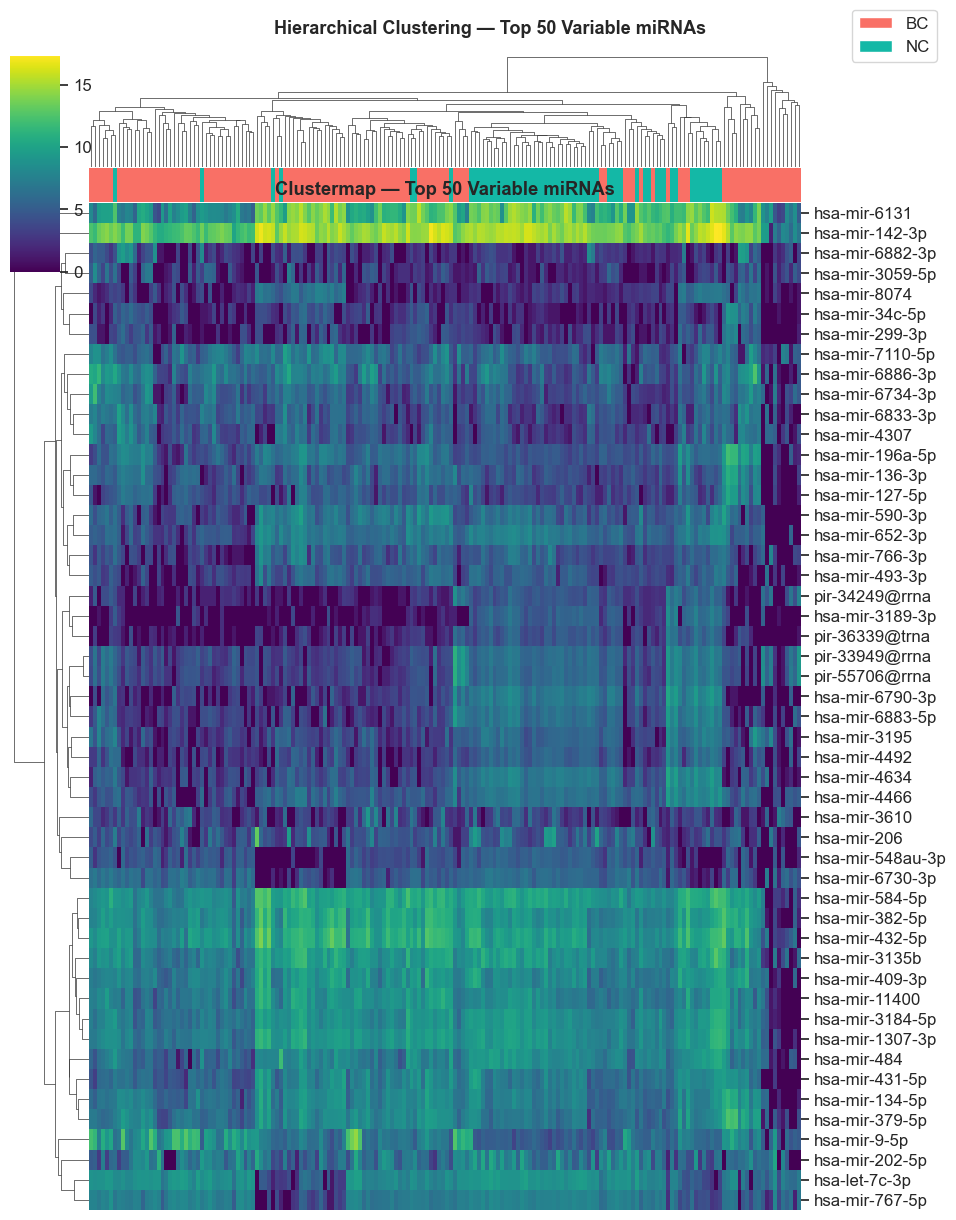

In [37]:
top50 = df_log.var(axis=1).nlargest(50).index
col_colors = labels.map(PAL)
g = sns.clustermap(df_log.loc[top50], cmap = 'viridis', col_colors = col_colors.values, figsize=(10, 12), yticklabels=True,
                   dendrogram_ratio=(0.1, 0.1), xticklabels=False)
g.ax_heatmap.set_title('Clustermap — Top 50 Variable miRNAs', fontweight='bold')
g.ax_heatmap.set_ylabel('')
g.fig.suptitle('Hierarchical Clustering — Top 50 Variable miRNAs',
               fontweight='bold', fontsize=13, y=1.01)
g.ax_heatmap.legend(handles=[Patch(fc=PAL['BC'], label='BC'), Patch(fc=PAL['NC'], label='NC')],
                    loc='upper left', bbox_to_anchor=(1.06, 1.2), frameon=True)
plt.show()

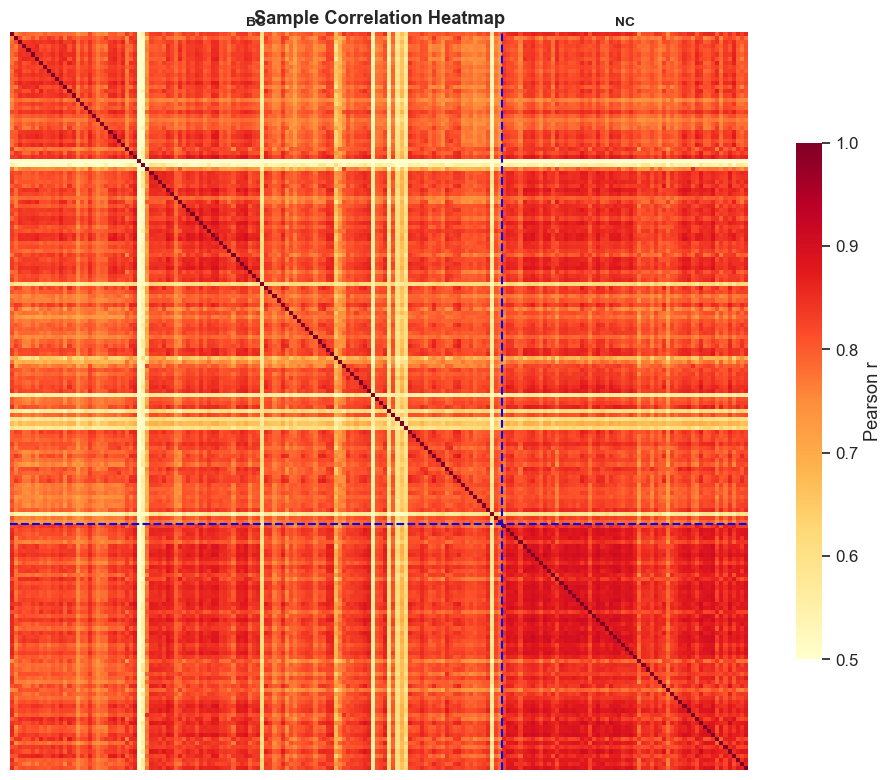

In [38]:
sample_corr = df_log.corr()
ordered = labels.sort_values().index

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(sample_corr.loc[ordered, ordered], cmap='YlOrRd', vmin=0.5, vmax=1, square=True,
            xticklabels=False, yticklabels=False, ax=ax, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
ax.set_title('Sample Correlation Heatmap', fontweight='bold')
ax.axhline(n_bc, color='blue', ls='--', lw=1.5)
ax.axvline(n_bc, color='blue', ls='--', lw=1.5)
ax.text(n_bc/2, -1.5, 'BC', ha='center', fontweight='bold', fontsize=10)
ax.text(n_bc + n_nc/2, -1.5, 'NC', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()